In [1]:
import sys
sys.path.insert(0, '../Results')
sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from python_utils.visualization_utils import perc, SetPlotRC, ApplyFont, format_results_for_jupyter_and_latex, print_experiment_summary_hyperparams
from python_utils.visualization_utils import plot_pcl_convergence_ci, plot_pcl_convergence_w_quantiles, plot_pcl_convergence_boxplot

import warnings
warnings.filterwarnings("ignore")

In [2]:
if not os.path.exists("Figures"):
    os.mkdir("Figures")

# dSprite Experiment Results with Log Cosh Loss Function

In [3]:
df_doubly_robustNME = pd.read_csv(r"../Results/dSprite_Experiment/DRPCLNET_dsprite_Results_with_log_cosh_2000_5000_10000_15000_20000_2026-04-08_19-23-56.csv")
df_DRKPV = pd.read_csv(r"../Results/dSprite_Experiment/DRKPV_dSprite_Results_2026-04-11_16-44-00.csv")
df_DRKPV = df_DRKPV.loc[df_DRKPV["Algorithm"] == "DRKPV"]

df_DRKPV_Nys_2000 = pd.read_csv(r"../Results/dSprite_Experiment/DRKPV_Nystrom_dSprite_Results_2026-05-06_12-02-13_2000data.csv")
df_DRKPV_Nys_5000 = pd.read_csv(r"../Results/dSprite_Experiment/DRKPV_Nystrom_dSprite_Results_2026-05-06_11-46-36_5000data.csv")
df_DRKPV_Nys_10000 = pd.read_csv(r"../Results/dSprite_Experiment/DRKPV_Nystrom_dSprite_Results_2026-05-06_11-13-59_10000data.csv")
df_DRKPV_Nys_15000 = pd.read_csv(r"../Results/dSprite_Experiment/DRKPV_Nystrom_dSprite_Results_2026-05-06_09-45-46_15000data.csv")
df_DRKPV_Nys_20000 = pd.read_csv(r"../Results/dSprite_Experiment/DRKPV_Nystrom_dSprite_Results_2026-05-05_23-20-10_20000data.csv")

df_DRKPV_Nys = pd.concat([df_DRKPV_Nys_2000, df_DRKPV_Nys_5000, df_DRKPV_Nys_10000, df_DRKPV_Nys_15000, df_DRKPV_Nys_20000], axis = 0)
df_DRKPV_Nys = df_DRKPV_Nys.loc[df_DRKPV_Nys['Algorithm'] == 'DRKPV_Nystrom']
# df_DRKPV_Nys['Algorithm'] = 

df_results = pd.concat([df_doubly_robustNME, df_DRKPV, df_DRKPV_Nys], axis = 0)
# df_results = df_doubly_robustNME.copy()
df_results.tail()

,Algorithm,Data_Size,Seed,Causal_MSE,out_experiment_name,out_device,out_disable_first_stage,out_lr_first_stage_base,out_lr_second_stage_ax,out_lr_second_stage_w,...,treat_second_stage_loss_name,treat_negative_penalty,third_lr,third_weight_decay,third_n_epochs,third_gap_penalty_weight,third_log_per_epoch,third_input_dim,third_output_dim,third_dropout_rate
75,DRKPV_Nystrom,20000,2500,21.967743,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,DRKPV_Nystrom,20000,2600,22.118271,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81,DRKPV_Nystrom,20000,2700,22.955257,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84,DRKPV_Nystrom,20000,2800,21.644746,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87,DRKPV_Nystrom,20000,2900,22.024649,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import numpy as np
import pandas as pd

# Safer version: explicitly attach Data_Size from the filename/load block
dfs = [
    (2000,  df_DRKPV_Nys_2000),
    (5000,  df_DRKPV_Nys_5000),
    (10000, df_DRKPV_Nys_10000),
    (15000, df_DRKPV_Nys_15000),
    (20000, df_DRKPV_Nys_20000),
]

df_DRKPV_Nys = []
for n, dfi in dfs:
    tmp = dfi.copy()
    tmp["Data_Size"] = n  # overwrite/ensure correct data size
    df_DRKPV_Nys.append(tmp)

df_DRKPV_Nys = pd.concat(df_DRKPV_Nys, axis=0, ignore_index=True)

# Keep DRKPV Nystrom only
df_DRKPV_Nys = df_DRKPV_Nys.loc[df_DRKPV_Nys["Algorithm"] == "DRKPV_Nystrom"].copy()

# Ensure numeric MSE
df_DRKPV_Nys["Causal_MSE"] = pd.to_numeric(df_DRKPV_Nys["Causal_MSE"], errors="coerce")
df_DRKPV_Nys = df_DRKPV_Nys.dropna(subset=["Causal_MSE", "Data_Size"])

summary_mse = (
    df_DRKPV_Nys
    .groupby("Data_Size")["Causal_MSE"]
    .agg(
        n_runs="count",
        mean_mse="mean",
        std_mse="std",
        median_mse="median",
        min_mse="min",
        max_mse="max",
    )
    .reset_index()
    .sort_values("Data_Size")
)

summary_mse["sem_mse"] = summary_mse["std_mse"] / np.sqrt(summary_mse["n_runs"])
summary_mse["ci95_low"] = summary_mse["mean_mse"] - 1.96 * summary_mse["sem_mse"]
summary_mse["ci95_high"] = summary_mse["mean_mse"] + 1.96 * summary_mse["sem_mse"]

# Relative change compared to n=2000
baseline = summary_mse.loc[summary_mse["Data_Size"] == 2000, "mean_mse"]
if len(baseline) > 0:
    baseline = baseline.iloc[0]
    summary_mse["rel_to_2000"] = summary_mse["mean_mse"] / baseline
    summary_mse["pct_change_vs_2000"] = 100 * (summary_mse["mean_mse"] / baseline - 1)

# Nice display formatting
summary_mse_display = summary_mse.copy()
for col in ["mean_mse", "std_mse", "median_mse", "min_mse", "max_mse", "sem_mse", "ci95_low", "ci95_high"]:
    summary_mse_display[col] = summary_mse_display[col].map(lambda x: f"{x:.4e}")

if "rel_to_2000" in summary_mse_display.columns:
    summary_mse_display["rel_to_2000"] = summary_mse_display["rel_to_2000"].map(lambda x: f"{x:.3f}")
    summary_mse_display["pct_change_vs_2000"] = summary_mse_display["pct_change_vs_2000"].map(lambda x: f"{x:.2f}%")

summary_mse_display

,Data_Size,n_runs,mean_mse,std_mse,median_mse,min_mse,max_mse,sem_mse,ci95_low,ci95_high,rel_to_2000,pct_change_vs_2000
0,2000,30,2.2052e+01,9.8534e-01,2.2013e+01,1.9820e+01,2.3879e+01,1.7990e-01,2.1699e+01,2.2404e+01,1.000,0.00%
1,5000,30,2.1624e+01,1.1044e+00,2.1529e+01,2.0131e+01,2.4328e+01,2.0163e-01,2.1229e+01,2.2019e+01,0.981,-1.94%
2,10000,30,2.1523e+01,6.9642e-01,2.1295e+01,2.0695e+01,2.3627e+01,1.2715e-01,2.1273e+01,2.1772e+01,0.976,-2.40%
3,15000,30,2.1415e+01,6.0322e-01,2.1496e+01,2.0426e+01,2.2512e+01,1.1013e-01,2.1199e+01,2.1630e+01,0.971,-2.89%
4,20000,30,2.1594e+01,7.7257e-01,2.1500e+01,2.0485e+01,2.4076e+01,1.4105e-01,2.1317e+01,2.1870e+01,0.979,-2.08%


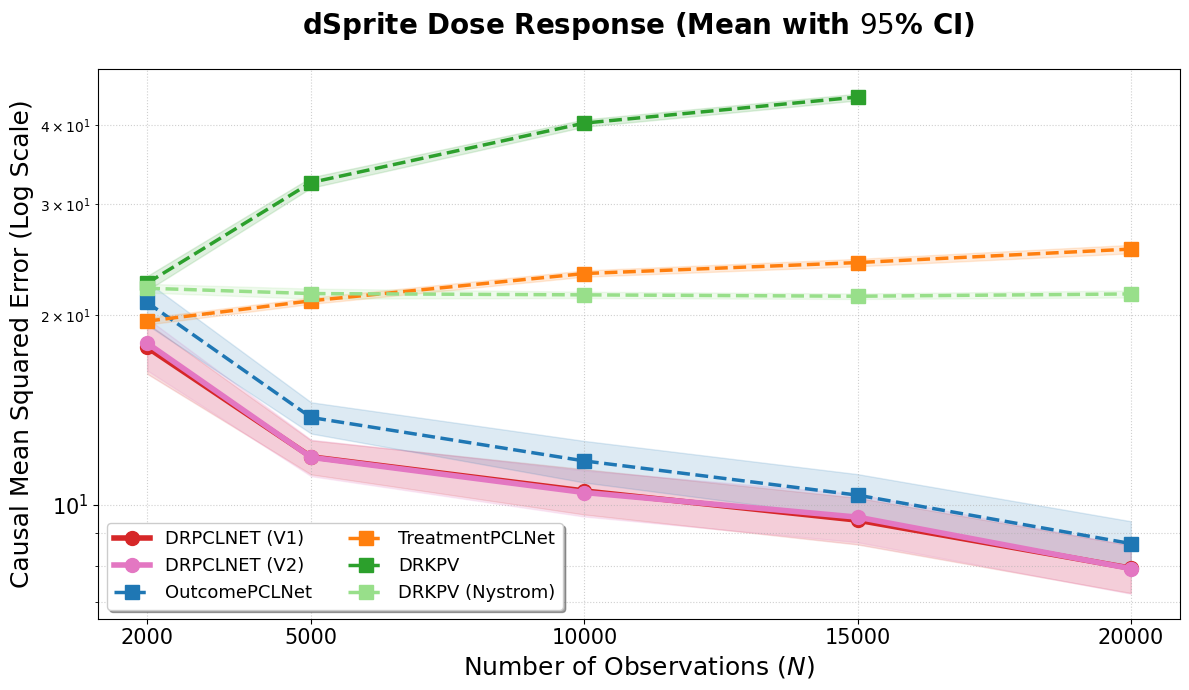

In [5]:
plot_title = f"dSprite Dose Response (Mean with $95$% CI)"
dsprite_plot = plot_pcl_convergence_ci(df_results, title = plot_title)
# plt.savefig('Figures/DRPCLNET_dSprite_Comparison.pdf', format='pdf', bbox_inches = 'tight')
dsprite_plot.show()

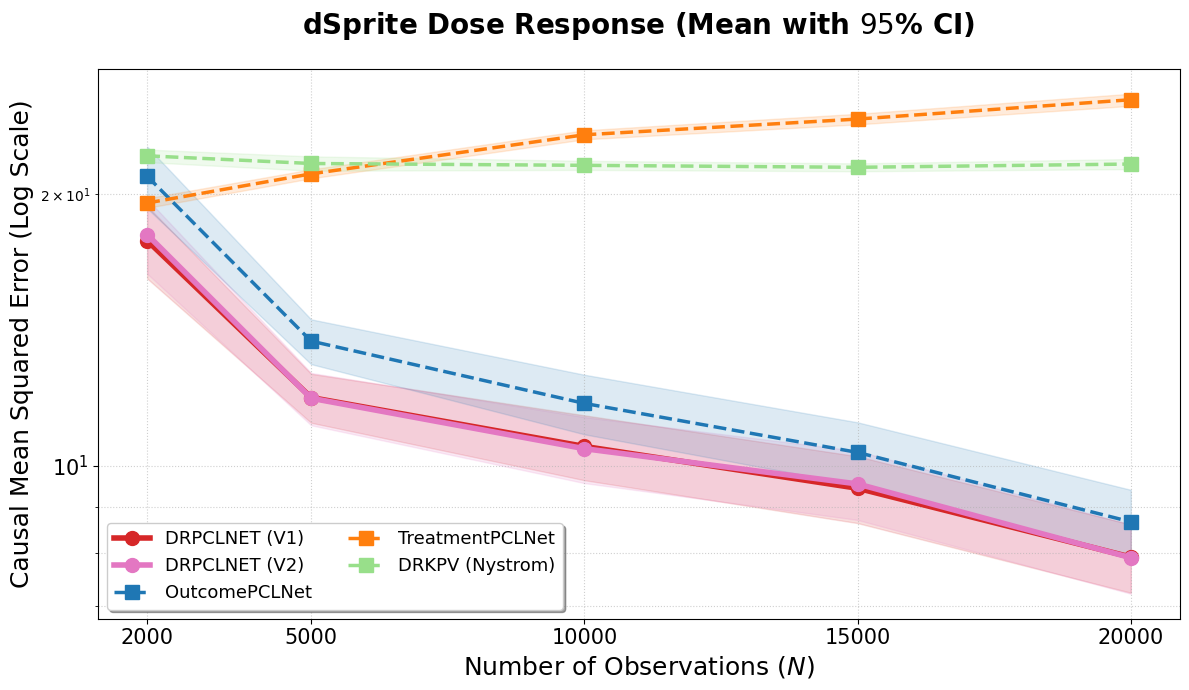

In [6]:
plot_title = f"dSprite Dose Response (Mean with $95$% CI)"
dsprite_plot = plot_pcl_convergence_ci(df_results.loc[df_results["Algorithm"] != 'DRKPV'], title = plot_title)
plt.savefig('Figures/DRPCLNET_dSprite_Comparison.pdf', format='pdf', bbox_inches = 'tight')
dsprite_plot.show()

In [7]:
format_results_for_jupyter_and_latex(df_results, "dSprite", precision=6)

--- Jupyter Visual Preview ---


In [8]:
print_experiment_summary_hyperparams(df_doubly_robustNME)

🚀 EXPERIMENT HYPERPARAMETER SUMMARY

📊 DATA SIZE: N = 2000
------------------------------

  🔹 Outcome Bridge (First/Second Stage):
    experiment_name          : outcome_bridge_dSprite_v1
    device                   : cuda
    disable_first_stage      : False
    lr_first_stage_base      : 0.0001
    lr_second_stage_ax       : 0.0001
    lr_second_stage_w        : 0.0001
    second_stage_head_lr     : 0.01
    weight_decay             : 1e-05
    first_stage_momentum     : 0.9
    second_stage_momentum    : 0.9
    scheduler_gamma          : 0.99
    n_epochs                 : 100.0
    stage1_iter              : 10.0
    stage2_iter              : 1.0
    second_stage_head_steps  : 5.0
    log_per_epoch            : 10.0
    plot_loss                : False
    reg_annealing_method     : exponential
    consider_prev_weight     : True
    first_stage_loss_name    : mse
    second_stage_loss_name   : log_cosh

  🔹 Treatment Bridge (First/Second Stage):
    experiment_name          : 

# dSprite with other Loss Functions

In [9]:
df_huber = pd.read_csv(r"../Results/dSprite_Experiment/DRPCLNET_dsprite_Results_with_huber_2000_5000_10000_15000_20000_2026-04-11_18-59-54.csv")

In [10]:
format_results_for_jupyter_and_latex(df_huber, "dSprite", precision=6)

--- Jupyter Visual Preview ---


In [11]:
df_mse = pd.read_csv(r"../Results/dSprite_Experiment/DRPCLNET_dsprite_Results_with_mse_2000_5000_10000_15000_20000_2026-04-11_19-02-09.csv")

In [12]:
format_results_for_jupyter_and_latex(df_mse, "dSprite", precision=6)

--- Jupyter Visual Preview ---


In [13]:
df_closedForm = pd.read_csv(r"../Results/dSprite_Experiment/DRPCLNET_dsprite_Results_with_mse_2000_5000_10000_15000_20000_2026-04-12_11-50-04.csv")

In [14]:
format_results_for_jupyter_and_latex(df_closedForm, "dSprite", precision=6)

--- Jupyter Visual Preview ---
